In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("bank.csv")

print(df.head())
print(df.shape)
print(df.info())

FileNotFoundError: [Errno 2] No such file or directory: 'bank.csv'

In [2]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  if fn == 'bank.csv':
    df = pd.read_csv(io.StringIO(uploaded[fn].decode('utf-8')))
    print(df.head())
    print(df.shape)
    print(df.info())

Saving bank.csv to bank.csv
User uploaded file "bank.csv" with length 918960 bytes
   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
(11162, 17)
<cla

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("bank.csv")

print(df.head())
print(df.shape)
print(df.info())

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
(11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data column

In [4]:
df['deposit'].value_counts()

,count
deposit,
no,5873
yes,5289


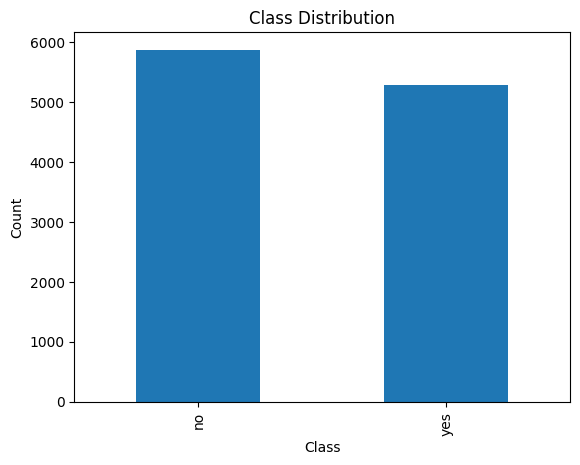

In [5]:
df['deposit'].value_counts().plot(kind='bar')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [6]:
majority = df[df['deposit'] == 'no']
minority = df[df['deposit'] == 'yes'].sample(n=1000, random_state=42)

df_imbalanced = pd.concat([majority, minority])

print(df_imbalanced['deposit'].value_counts())

deposit
no     5873
yes    1000
Name: count, dtype: int64


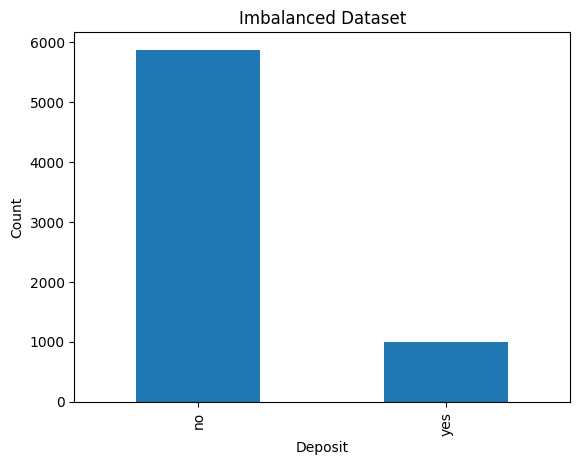

In [7]:
df_imbalanced['deposit'].value_counts().plot(kind='bar')
plt.title('Imbalanced Dataset')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.show()

In [8]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# تحويل target إلى أرقام
df_imbalanced['deposit'] = df_imbalanced['deposit'].map({'no': 0, 'yes': 1})

# فصل X و y
X = df_imbalanced.drop('deposit', axis=1)
y = df_imbalanced['deposit']

# تحويل الأعمدة النصية إلى أرقام
X = pd.get_dummies(X, drop_first=True)

# تطبيع البيانات بين 0 و 1
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("X shape:", X_scaled.shape)
print("y shape:", y.shape)

X shape: (6873, 42)
y shape: (6873,)


In [9]:
import numpy as np

minority_data = X_scaled[y == 1]

print("Minority class shape:", minority_data.shape)

Minority class shape: (1000, 42)


In [10]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LeakyReLU
from tensorflow.keras.optimizers import Adam
import numpy as np

data_dim = minority_data.shape[1]
latent_dim = 32

In [11]:
def build_generator():
    model = Sequential([
        Dense(64, input_dim=latent_dim),
        LeakyReLU(0.2),
        Dense(128),
        LeakyReLU(0.2),
        Dense(data_dim, activation='sigmoid')
    ])
    return model

In [12]:
def build_discriminator():
    model = Sequential([
        Dense(128, input_dim=data_dim),
        LeakyReLU(0.2),
        Dense(64),
        LeakyReLU(0.2),
        Dense(1, activation='sigmoid')
    ])

    model.compile(
        loss='binary_crossentropy',
        optimizer=Adam(0.0002),
        metrics=['accuracy']
    )

    return model

In [13]:
generator = build_generator()
discriminator = build_discriminator()

discriminator.trainable = False

gan = Sequential([generator, discriminator])

gan.compile(
    loss='binary_crossentropy',
    optimizer=Adam(0.0002)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
def train_gan(data, epochs=1000, batch_size=32):
    half_batch = batch_size // 2

    for epoch in range(epochs):

        idx = np.random.randint(0, data.shape[0], half_batch)
        real_samples = data[idx]

        noise = np.random.normal(0, 1, (half_batch, latent_dim))
        fake_samples = generator.predict(noise, verbose=0)

        discriminator.trainable = True
        d_loss_real = discriminator.train_on_batch(
            real_samples,
            np.ones((half_batch, 1))
        )

        d_loss_fake = discriminator.train_on_batch(
            fake_samples,
            np.zeros((half_batch, 1))
        )

        d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

        discriminator.trainable = False

        noise = np.random.normal(0, 1, (batch_size, latent_dim))
        g_loss = gan.train_on_batch(
            noise,
            np.ones((batch_size, 1))
        )

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, D Loss: {d_loss[0]:.4f}, G Loss: {g_loss:.4f}")

In [15]:
generator.summary()
discriminator.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 42)             │         5,418 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,850 (61.91 KB)

 Trainable params: 15,850 (61.91 KB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 13,825 (54.00 KB)

In [16]:
train_gan(minority_data, epochs=1000, batch_size=32)

Epoch 0, D Loss: 0.6803, G Loss: 0.6240
Epoch 100, D Loss: 0.4304, G Loss: 1.2738
Epoch 200, D Loss: 0.4193, G Loss: 1.2317
Epoch 300, D Loss: 0.4239, G Loss: 1.1616
Epoch 400, D Loss: 0.3972, G Loss: 1.2211
Epoch 500, D Loss: 0.3860, G Loss: 1.2734
Epoch 600, D Loss: 0.3752, G Loss: 1.3006
Epoch 700, D Loss: 0.3461, G Loss: 1.4042
Epoch 800, D Loss: 0.3414, G Loss: 1.4283
Epoch 900, D Loss: 0.3270, G Loss: 1.5037


In [17]:
num_samples = 4873

noise = np.random.normal(0, 1, (num_samples, latent_dim))
synthetic_vanilla = generator.predict(noise)

print(synthetic_vanilla.shape)

153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
(4873, 42)


In [18]:
X_vanilla_balanced = np.vstack((X_scaled, synthetic_vanilla))

y_vanilla_balanced = np.hstack((
    y,
    np.ones(num_samples)
))

print("X Vanilla Balanced:", X_vanilla_balanced.shape)
print("y Vanilla Balanced:", y_vanilla_balanced.shape)

unique, counts = np.unique(y_vanilla_balanced, return_counts=True)
print(dict(zip(unique, counts)))

X Vanilla Balanced: (11746, 42)
y Vanilla Balanced: (11746,)
{np.float64(0.0): np.int64(5873), np.float64(1.0): np.int64(5873)}


In [19]:
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, Dense, LeakyReLU
from tensorflow.keras.optimizers import RMSprop
import tensorflow as tf

In [21]:
def build_wgan_generator():
    model = Sequential([
        Input(shape=(latent_dim,)),
        Dense(64),
        LeakyReLU(0.2),
        Dense(128),
        LeakyReLU(0.2),
        Dense(data_dim, activation='sigmoid')
    ])
    return model


def build_wgan_critic():
    model = Sequential([
        Input(shape=(data_dim,)),
        Dense(128),
        LeakyReLU(0.2),
        Dense(64),
        LeakyReLU(0.2),
        Dense(1)
    ])
    return model

In [22]:
wgan_generator = build_wgan_generator()
wgan_critic = build_wgan_critic()

critic_optimizer = RMSprop(learning_rate=0.00005)
generator_optimizer = RMSprop(learning_rate=0.00005)

In [23]:
def train_wgan(data, epochs=1000, batch_size=32, n_critic=5, clip_value=0.01):
    for epoch in range(epochs):

        for _ in range(n_critic):
            idx = np.random.randint(0, data.shape[0], batch_size)
            real_samples = data[idx]

            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_samples = wgan_generator(noise, training=True)

            with tf.GradientTape() as tape:
                real_output = wgan_critic(real_samples, training=True)
                fake_output = wgan_critic(fake_samples, training=True)
                critic_loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output)

            grads = tape.gradient(critic_loss, wgan_critic.trainable_variables)
            critic_optimizer.apply_gradients(zip(grads, wgan_critic.trainable_variables))

            for weight in wgan_critic.trainable_variables:
                weight.assign(tf.clip_by_value(weight, -clip_value, clip_value))

        noise = np.random.normal(0, 1, (batch_size, latent_dim))

        with tf.GradientTape() as tape:
            fake_samples = wgan_generator(noise, training=True)
            fake_output = wgan_critic(fake_samples, training=True)
            generator_loss = -tf.reduce_mean(fake_output)

        grads = tape.gradient(generator_loss, wgan_generator.trainable_variables)
        generator_optimizer.apply_gradients(zip(grads, wgan_generator.trainable_variables))

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Critic Loss: {critic_loss.numpy():.4f}, Generator Loss: {generator_loss.numpy():.4f}")

In [24]:
train_wgan(minority_data, epochs=1000, batch_size=32)

Epoch 0, Critic Loss: -0.0001, Generator Loss: 0.0002
Epoch 100, Critic Loss: -0.0263, Generator Loss: 0.0206
Epoch 200, Critic Loss: -0.0454, Generator Loss: 0.0277
Epoch 300, Critic Loss: -0.0471, Generator Loss: 0.0271
Epoch 400, Critic Loss: -0.0469, Generator Loss: 0.0272
Epoch 500, Critic Loss: -0.0423, Generator Loss: 0.0267
Epoch 600, Critic Loss: -0.0441, Generator Loss: 0.0261
Epoch 700, Critic Loss: -0.0415, Generator Loss: 0.0253
Epoch 800, Critic Loss: -0.0407, Generator Loss: 0.0251
Epoch 900, Critic Loss: -0.0380, Generator Loss: 0.0235


In [25]:
noise = np.random.normal(0, 1, (num_samples, latent_dim))
synthetic_wgan = wgan_generator.predict(noise)

print(synthetic_wgan.shape)

153/153 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(4873, 42)


In [26]:
X_wgan_balanced = np.vstack((X_scaled, synthetic_wgan))

y_wgan_balanced = np.hstack((
    y,
    np.ones(num_samples)
))

print("X WGAN Balanced:", X_wgan_balanced.shape)
print("y WGAN Balanced:", y_wgan_balanced.shape)

unique, counts = np.unique(y_wgan_balanced, return_counts=True)
print(dict(zip(unique, counts)))

X WGAN Balanced: (11746, 42)
y WGAN Balanced: (11746,)
{np.float64(0.0): np.int64(5873), np.float64(1.0): np.int64(5873)}


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix


In [28]:
def train_and_evaluate(X, y, name):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.3,
        random_state=42,
        stratify=y
    )

    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Dataset": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    }

    print(name)
    print(confusion_matrix(y_test, y_pred))
    print(results)
    print()

    return results

In [29]:
results_original = train_and_evaluate(X_scaled, y, "Original Imbalanced")
results_vanilla = train_and_evaluate(X_vanilla_balanced, y_vanilla_balanced, "Vanilla GAN Balanced")
results_wgan = train_and_evaluate(X_wgan_balanced, y_wgan_balanced, "WGAN Balanced")

Original Imbalanced
[[1703   59]
 [ 192  108]]
{'Dataset': 'Original Imbalanced', 'Accuracy': 0.8782735208535403, 'Precision': 0.6467065868263473, 'Recall': 0.36, 'F1-score': 0.4625267665952891, 'AUC-ROC': np.float64(0.9107377979568672)}

Vanilla GAN Balanced
[[1711   51]
 [ 198 1564]]
{'Dataset': 'Vanilla GAN Balanced', 'Accuracy': 0.9293416572077186, 'Precision': 0.968421052631579, 'Recall': 0.887627695800227, 'F1-score': 0.9262659164939295, 'AUC-ROC': np.float64(0.9851981418803573)}

WGAN Balanced
[[1712   50]
 [ 194 1568]]
{'Dataset': 'WGAN Balanced', 'Accuracy': 0.9307604994324631, 'Precision': 0.969097651421508, 'Recall': 0.8898978433598184, 'F1-score': 0.927810650887574, 'AUC-ROC': np.float64(0.9851454788375092)}



In [30]:
#Result comparison
import pandas as pd

results_df = pd.DataFrame([
    results_original,
    results_vanilla,
    results_wgan
])

print(results_df)

                Dataset  Accuracy  Precision    Recall  F1-score   AUC-ROC
0   Original Imbalanced  0.878274   0.646707  0.360000  0.462527  0.910738
1  Vanilla GAN Balanced  0.929342   0.968421  0.887628  0.926266  0.985198
2         WGAN Balanced  0.930760   0.969098  0.889898  0.927811  0.985145


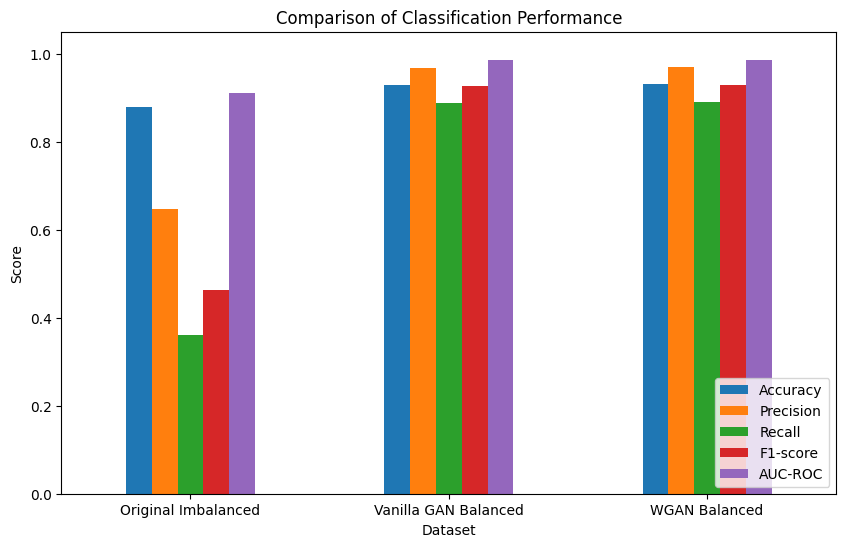

In [31]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC-ROC']

results_df.set_index('Dataset')[metrics].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Comparison of Classification Performance')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()